# Gaussian Basics for Generative Models

This notebook covers the essential properties of Gaussian (normal) distributions that underpin modern generative models such as **Variational Autoencoders (VAEs)** and **Diffusion Models**.

We will build intuition through interactive visualisations, starting from univariate Gaussians and progressing to multivariate distributions, the reparameterisation trick, and a first look at how progressive Gaussian noise relates to the forward diffusion process.

**Runtime:** Google Colab with an L4 GPU is recommended.

In [1]:
# ---- Colab / environment setup ----
!pip install -q torch torchvision matplotlib numpy scipy

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, multivariate_normal
import torchvision
import torchvision.transforms as transforms

%matplotlib inline

# --- Device detection ---
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS")
else:
    device = torch.device("cpu")
    print("Using CPU")

# --- Reproducibility ---
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch {torch.__version__}  |  NumPy {np.__version__}  |  Device: {device}")

Using CUDA: NVIDIA L4
PyTorch 2.10.0+cu128  |  NumPy 2.0.2  |  Device: cuda


## 1. Univariate Gaussian Distributions

The probability density function (PDF) of a univariate Gaussian is:

$$p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x - \mu)^2}{2\sigma^2}\right)$$

Below we plot three Gaussians with different means and variances to see how these parameters control the shape.

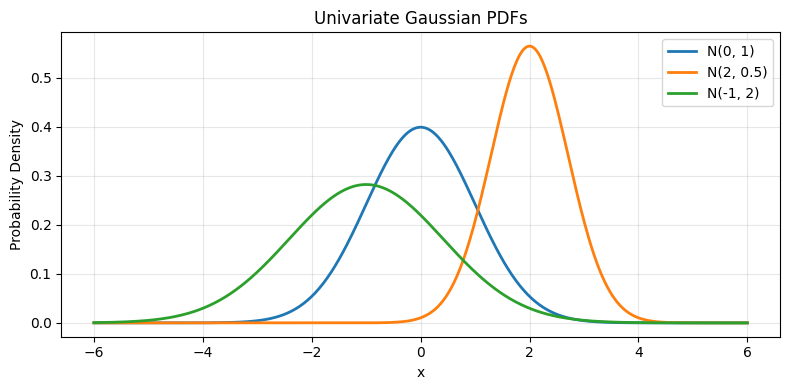

In [2]:
x = np.linspace(-6, 6, 500)

params = [
    (0, 1,   "N(0, 1)"),
    (2, 0.5, "N(2, 0.5)"),
    (-1, 2,  "N(-1, 2)"),
]

fig, ax = plt.subplots(figsize=(8, 4))
for mu, sigma, label in params:
    ax.plot(x, norm.pdf(x, loc=mu, scale=np.sqrt(sigma)), linewidth=2, label=label)

ax.set_xlabel("x")
ax.set_ylabel("Probability Density")
ax.set_title("Univariate Gaussian PDFs")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Sampling & Histogram Convergence

As we draw more samples from a distribution, the empirical histogram converges to the true PDF. This is a visual demonstration of the **Law of Large Numbers**.

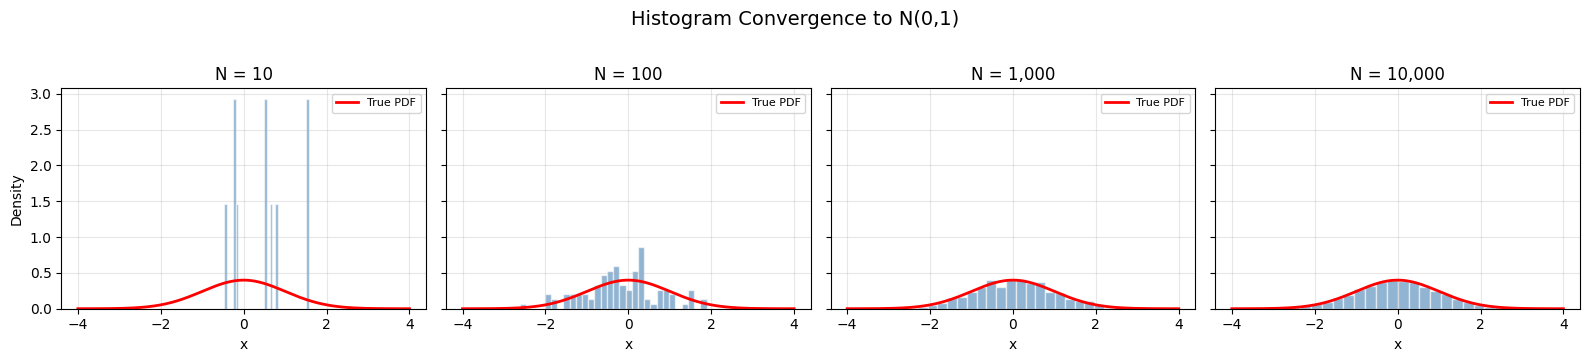

In [3]:
sample_sizes = [10, 100, 1_000, 10_000]
x_range = np.linspace(-4, 4, 300)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, N in zip(axes, sample_sizes):
    samples = np.random.randn(N)
    ax.hist(samples, bins=30, density=True, alpha=0.6, color="steelblue", edgecolor="white")
    ax.plot(x_range, norm.pdf(x_range), "r-", linewidth=2, label="True PDF")
    ax.set_title(f"N = {N:,}")
    ax.set_xlabel("x")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Density")
fig.suptitle("Histogram Convergence to N(0,1)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Central Limit Theorem

The **Central Limit Theorem (CLT)** states that the sum of many independent random variables (regardless of their original distribution) tends toward a Gaussian. Below we sum K independent Uniform(0,1) variables and watch the distribution become increasingly Gaussian.

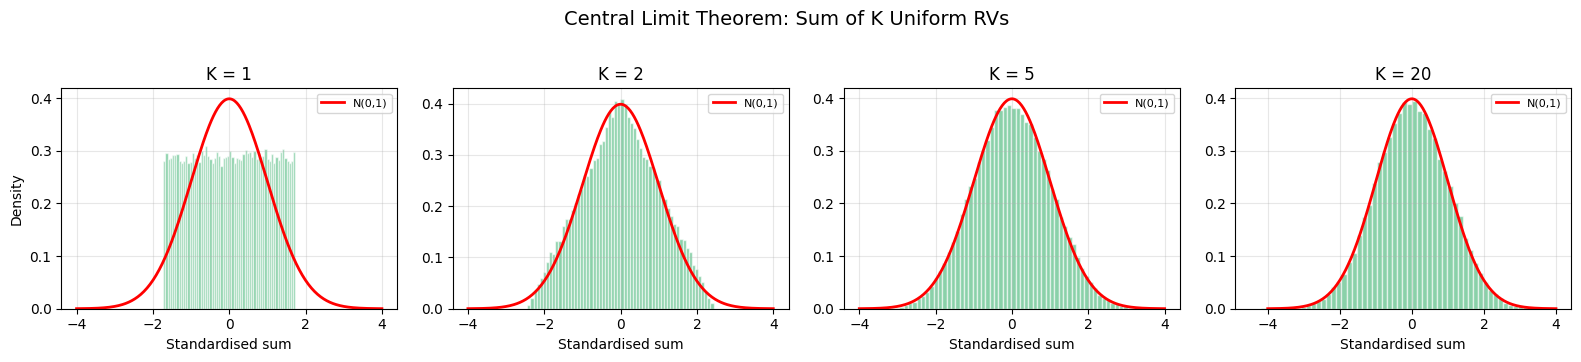

In [4]:
K_values = [1, 2, 5, 20]
n_samples = 50_000

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=False)

for ax, K in zip(axes, K_values):
    # Sum of K uniform [0,1) variables
    sums = np.sum(np.random.rand(n_samples, K), axis=1)
    # Standardise: mean = K/2, var = K/12
    standardised = (sums - K / 2) / np.sqrt(K / 12)

    ax.hist(standardised, bins=60, density=True, alpha=0.6, color="mediumseagreen", edgecolor="white")
    x_range = np.linspace(-4, 4, 300)
    ax.plot(x_range, norm.pdf(x_range), "r-", linewidth=2, label="N(0,1)")
    ax.set_title(f"K = {K}")
    ax.set_xlabel("Standardised sum")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Density")
fig.suptitle("Central Limit Theorem: Sum of K Uniform RVs", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Multivariate Gaussian Distributions

A 2-D Gaussian is parameterised by a mean vector $\boldsymbol{\mu} \in \mathbb{R}^2$ and a $2 \times 2$ covariance matrix $\boldsymbol{\Sigma}$:

$$p(\mathbf{x}) = \frac{1}{2\pi |\boldsymbol{\Sigma}|^{1/2}} \exp\!\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right)$$

The shape of the covariance matrix controls the geometry of the iso-density contours:

| Covariance type | Contour shape |
|---|---|
| $\sigma^2 I$ (scalar times identity) | Circle |
| Diagonal (different variances) | Axis-aligned ellipse |
| Full (with off-diagonal terms) | Rotated ellipse |

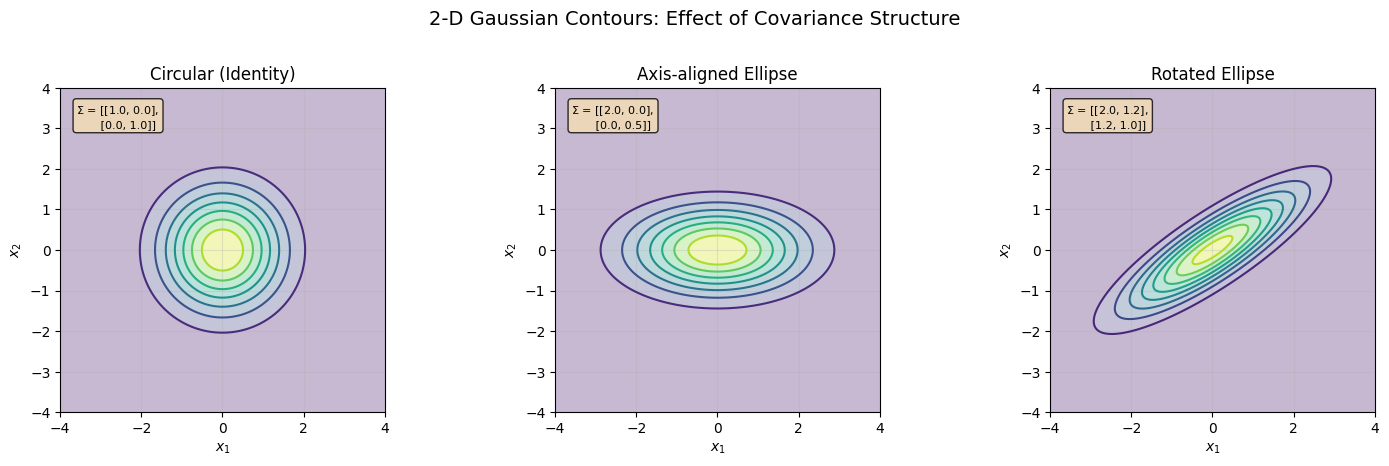

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Define the three covariance matrices
cov_configs = [
    ("Circular (Identity)",      np.array([[1.0, 0.0], [0.0, 1.0]])),
    ("Axis-aligned Ellipse",     np.array([[2.0, 0.0], [0.0, 0.5]])),
    ("Rotated Ellipse",          np.array([[2.0, 1.2], [1.2, 1.0]])),
]

mean = np.array([0.0, 0.0])

for ax, (title, cov) in zip(axes, cov_configs):
    # Create grid
    x_grid = np.linspace(-4, 4, 200)
    y_grid = np.linspace(-4, 4, 200)
    X, Y = np.meshgrid(x_grid, y_grid)
    pos = np.dstack((X, Y))

    rv = multivariate_normal(mean, cov)
    Z = rv.pdf(pos)

    contour = ax.contour(X, Y, Z, levels=8, cmap="viridis")
    ax.contourf(X, Y, Z, levels=8, cmap="viridis", alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

    # Annotate covariance matrix
    cov_str = f"$\\Sigma$ = [[{cov[0,0]:.1f}, {cov[0,1]:.1f}],\n       [{cov[1,0]:.1f}, {cov[1,1]:.1f}]]"
    ax.text(0.05, 0.95, cov_str, transform=ax.transAxes, fontsize=8,
            verticalalignment="top", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

fig.suptitle("2-D Gaussian Contours: Effect of Covariance Structure", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Marginal Distributions

Given a joint 2-D Gaussian, each marginal is simply a 1-D Gaussian whose mean and variance come from the corresponding entry of $\boldsymbol{\mu}$ and $\boldsymbol{\Sigma}$. We visualise this by plotting a scatter of joint samples together with histograms of each marginal on the top and right axes.

/tmp/ipython-input-15588/383531331.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


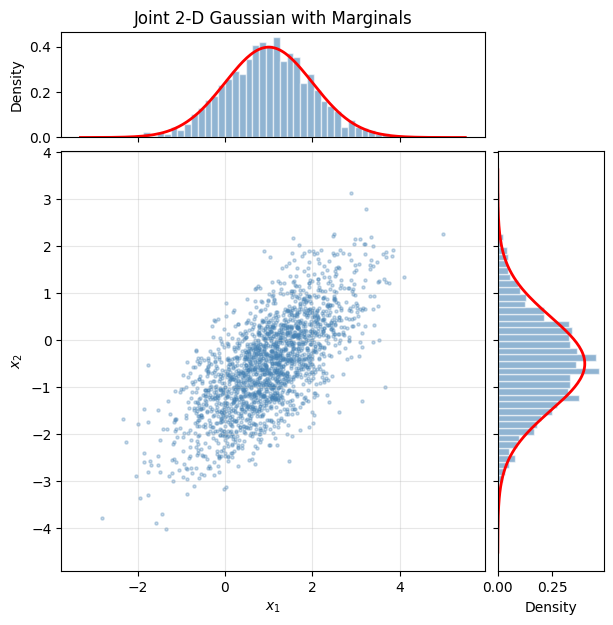

In [6]:
# Parameters for the joint distribution
mu_joint = np.array([1.0, -0.5])
cov_joint = np.array([[1.0, 0.7],
                      [0.7, 1.0]])

samples_2d = np.random.multivariate_normal(mu_joint, cov_joint, size=2000)

# Create figure with gridspec for marginals
fig = plt.figure(figsize=(7, 7))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                      wspace=0.05, hspace=0.05)

ax_joint = fig.add_subplot(gs[1, 0])
ax_marg_x = fig.add_subplot(gs[0, 0], sharex=ax_joint)
ax_marg_y = fig.add_subplot(gs[1, 1], sharey=ax_joint)

# Joint scatter
ax_joint.scatter(samples_2d[:, 0], samples_2d[:, 1], s=5, alpha=0.3, color="steelblue")
ax_joint.set_xlabel("$x_1$")
ax_joint.set_ylabel("$x_2$")
ax_joint.grid(True, alpha=0.3)

# Marginal x1 (top)
ax_marg_x.hist(samples_2d[:, 0], bins=50, density=True, alpha=0.6, color="steelblue", edgecolor="white")
x_range = np.linspace(samples_2d[:, 0].min() - 0.5, samples_2d[:, 0].max() + 0.5, 200)
ax_marg_x.plot(x_range, norm.pdf(x_range, loc=mu_joint[0], scale=np.sqrt(cov_joint[0, 0])), "r-", lw=2)
ax_marg_x.tick_params(labelbottom=False)
ax_marg_x.set_ylabel("Density")
ax_marg_x.set_title("Joint 2-D Gaussian with Marginals", fontsize=12)

# Marginal x2 (right)
ax_marg_y.hist(samples_2d[:, 1], bins=50, density=True, alpha=0.6, color="steelblue",
               edgecolor="white", orientation="horizontal")
y_range = np.linspace(samples_2d[:, 1].min() - 0.5, samples_2d[:, 1].max() + 0.5, 200)
ax_marg_y.plot(norm.pdf(y_range, loc=mu_joint[1], scale=np.sqrt(cov_joint[1, 1])), y_range, "r-", lw=2)
ax_marg_y.tick_params(labelleft=False)
ax_marg_y.set_xlabel("Density")

# Hide top-right corner
ax_empty = fig.add_subplot(gs[0, 1])
ax_empty.axis("off")

plt.tight_layout()
plt.show()

## 6. Conditional Distributions

For a 2-D Gaussian with correlation, fixing one variable gives a 1-D Gaussian over the other. If

$$\begin{pmatrix} x_1 \\ x_2 \end{pmatrix} \sim \mathcal{N}\!\left(\begin{pmatrix} \mu_1 \\ \mu_2 \end{pmatrix}, \begin{pmatrix} \sigma_1^2 & \rho\sigma_1\sigma_2 \\ \rho\sigma_1\sigma_2 & \sigma_2^2 \end{pmatrix}\right)$$

then

$$x_2 \mid x_1 \sim \mathcal{N}\!\left(\mu_2 + \rho\frac{\sigma_2}{\sigma_1}(x_1 - \mu_1),\; \sigma_2^2(1 - \rho^2)\right)$$

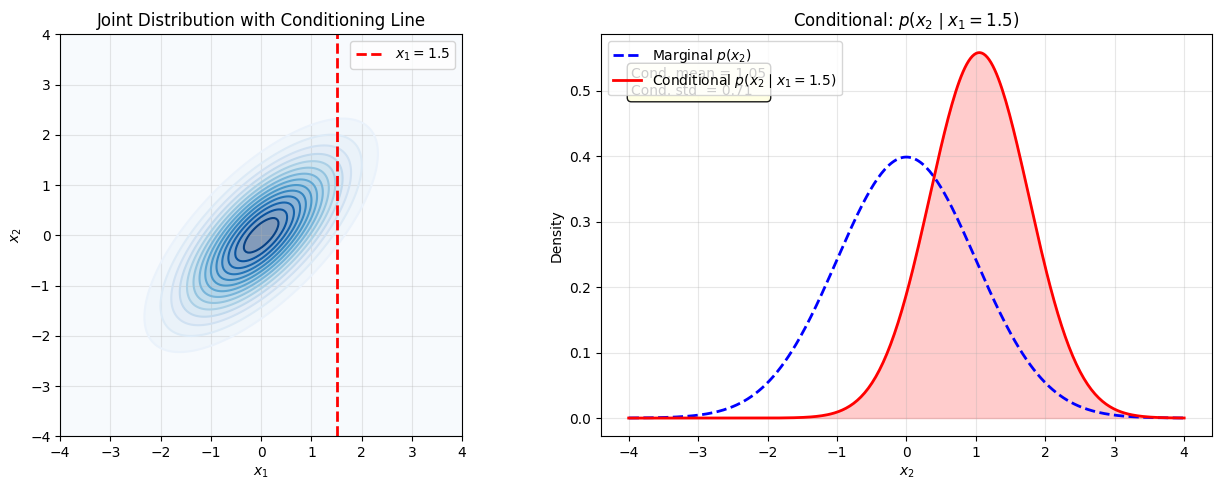

In [7]:
# Joint parameters
mu1, mu2 = 0.0, 0.0
sigma1, sigma2 = 1.0, 1.0
rho = 0.7
cov_cond = np.array([[sigma1**2, rho * sigma1 * sigma2],
                     [rho * sigma1 * sigma2, sigma2**2]])
mean_cond = np.array([mu1, mu2])

# Fix x1
x1_fixed = 1.5

# Conditional parameters: p(x2 | x1 = 1.5)
cond_mean = mu2 + rho * (sigma2 / sigma1) * (x1_fixed - mu1)
cond_var = sigma2**2 * (1 - rho**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: joint contour with the conditioning line
ax = axes[0]
x_grid = np.linspace(-4, 4, 200)
y_grid = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x_grid, y_grid)
pos = np.dstack((X, Y))
rv = multivariate_normal(mean_cond, cov_cond)
Z = rv.pdf(pos)

ax.contourf(X, Y, Z, levels=15, cmap="Blues", alpha=0.5)
ax.contour(X, Y, Z, levels=15, cmap="Blues")
ax.axvline(x1_fixed, color="red", linewidth=2, linestyle="--", label=f"$x_1 = {x1_fixed}$")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Joint Distribution with Conditioning Line")
ax.legend(fontsize=10)
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)

# Right: conditional distribution p(x2 | x1 = 1.5)
ax = axes[1]
x2_range = np.linspace(-4, 4, 300)
cond_pdf = norm.pdf(x2_range, loc=cond_mean, scale=np.sqrt(cond_var))
prior_pdf = norm.pdf(x2_range, loc=mu2, scale=sigma2)

ax.plot(x2_range, prior_pdf, "b--", linewidth=2, label="Marginal $p(x_2)$")
ax.plot(x2_range, cond_pdf, "r-", linewidth=2, label=f"Conditional $p(x_2 \\mid x_1={x1_fixed})$")
ax.fill_between(x2_range, cond_pdf, alpha=0.2, color="red")
ax.set_xlabel("$x_2$")
ax.set_ylabel("Density")
ax.set_title(f"Conditional: $p(x_2 \\mid x_1 = {x1_fixed})$")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax.text(0.05, 0.85, f"Cond. mean = {cond_mean:.2f}\nCond. std  = {np.sqrt(cond_var):.2f}",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))

plt.tight_layout()
plt.show()

## 7. The Reparameterization Trick

In a **Variational Autoencoder (VAE)** we need to back-propagate gradients through a sampling operation. The problem is that `z ~ N(mu, sigma^2)` is a stochastic node and we cannot differentiate through it directly.

The **reparameterization trick** rewrites the sample as a deterministic function of the parameters plus noise from a fixed distribution:

$$z = \mu + \sigma \cdot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, 1)$$

This way, $\mu$ and $\sigma$ are part of a deterministic computation graph, and gradients flow through them normally.

In [10]:
print("=" * 60)
print("Reparameterization Trick: Gradient Flow Demonstration")
print("=" * 60)

# --- Method 1: Reparameterization trick (gradients flow) ---
print("\n--- Method 1: Reparameterization Trick ---")
mu = torch.tensor([0.5], requires_grad=True)
log_sigma = torch.tensor([0.0], requires_grad=True)  # log(sigma) for numerical stability
sigma = torch.exp(log_sigma)

# Sample using the reparameterization trick
epsilon = torch.randn_like(mu)  # fixed noise from N(0,1)
z_reparam = mu + sigma * epsilon

# Compute a dummy loss and backprop
loss_reparam = (z_reparam - 2.0).pow(2).sum()
loss_reparam.backward()

print(f"  mu          = {mu.item():.4f}")
print(f"  sigma       = {sigma.item():.4f}")
print(f"  epsilon     = {epsilon.item():.4f}")
print(f"  z (sampled) = {z_reparam.item():.4f}")
print(f"  loss        = {loss_reparam.item():.4f}")
print(f"  grad(mu)       = {mu.grad.item():.4f}  <-- gradient flows!")
print(f"  grad(log_sigma)= {log_sigma.grad.item():.4f}  <-- gradient flows!")

# --- Method 2: Direct sampling (no gradients) ---
print("\n--- Method 2: Direct Sampling (torch.distributions) ---")
mu2 = torch.tensor([0.5], requires_grad=True)
log_sigma2 = torch.tensor([0.0], requires_grad=True)
sigma2 = torch.exp(log_sigma2)

dist = torch.distributions.Normal(mu2, sigma2)
z_direct = dist.sample()  # .sample() detaches from the graph

# To demonstrate that mu2.grad and log_sigma2.grad are None,
# loss_direct itself needs to require_grad for backward() to run.
# We add a dummy component that requires grad, but it won't affect
# the fact that z_direct's path to mu2/log_sigma2 is broken.
dummy_loss_component = torch.tensor(0.0, requires_grad=True)
loss_direct = (z_direct - 2.0).pow(2).sum() + dummy_loss_component

loss_direct.backward()

print(f"  mu          = {mu2.item():.4f}")
print(f"  sigma       = {sigma2.item():.4f}")
print(f"  z (sampled) = {z_direct.item():.4f}")
print(f"  loss        = {loss_direct.item():.4f}")
print(f"  grad(mu)        = {mu2.grad}  <-- None! No gradient.")
print(f"  grad(log_sigma) = {log_sigma2.grad}  <-- None! No gradient.")

# --- Method 3: rsample (PyTorch built-in reparameterization) ---
print("\n--- Method 3: dist.rsample() (built-in reparameterization) ---")
mu3 = torch.tensor([0.5], requires_grad=True)
log_sigma3 = torch.tensor([0.0], requires_grad=True)
sigma3 = torch.exp(log_sigma3)

dist3 = torch.distributions.Normal(mu3, sigma3)
z_rsample = dist3.rsample()  # reparameterized sample

loss_rsample = (z_rsample - 2.0).pow(2).sum()
loss_rsample.backward()

print(f"  mu          = {mu3.item():.4f}")
print(f"  sigma       = {sigma3.item():.4f}")
print(f"  z (sampled) = {z_rsample.item():.4f}")
print(f"  loss        = {loss_rsample.item():.4f}")
print(f"  grad(mu)        = {mu3.grad.item():.4f}  <-- gradient flows (rsample)!" )
print(f"  grad(log_sigma) = {log_sigma3.grad.item():.4f}  <-- gradient flows (rsample)!")

print("\n" + "=" * 60)
print("Key insight: .sample() breaks the gradient graph;")
print("the reparam trick (or .rsample()) keeps it intact.")
print("=" * 60)

Reparameterization Trick: Gradient Flow Demonstration

--- Method 1: Reparameterization Trick ---
  mu          = 0.5000
  sigma       = 1.0000
  epsilon     = -0.1863
  z (sampled) = 0.3137
  loss        = 2.8437
  grad(mu)       = -3.3727  <-- gradient flows!
  grad(log_sigma)= 0.6284  <-- gradient flows!

--- Method 2: Direct Sampling (torch.distributions) ---
  mu          = 0.5000
  sigma       = 1.0000
  z (sampled) = 2.7082
  loss        = 0.5015
  grad(mu)        = None  <-- None! No gradient.
  grad(log_sigma) = None  <-- None! No gradient.

--- Method 3: dist.rsample() (built-in reparameterization) ---
  mu          = 0.5000
  sigma       = 1.0000
  z (sampled) = -0.1380
  loss        = 4.5710
  grad(mu)        = -4.2760  <-- gradient flows (rsample)!
  grad(log_sigma) = 2.7281  <-- gradient flows (rsample)!

Key insight: .sample() breaks the gradient graph;
the reparam trick (or .rsample()) keeps it intact.


## 8. Bridge to Diffusion: Progressive Gaussian Noise

In **diffusion models**, the *forward process* gradually corrupts a clean image by adding Gaussian noise at each time step:

$$\mathbf{x}_t = \sqrt{1 - \beta_t}\, \mathbf{x}_{t-1} + \sqrt{\beta_t}\, \boldsymbol{\epsilon}, \qquad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

Here we preview this idea by directly adding increasing levels of Gaussian noise to an MNIST digit.

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.17MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


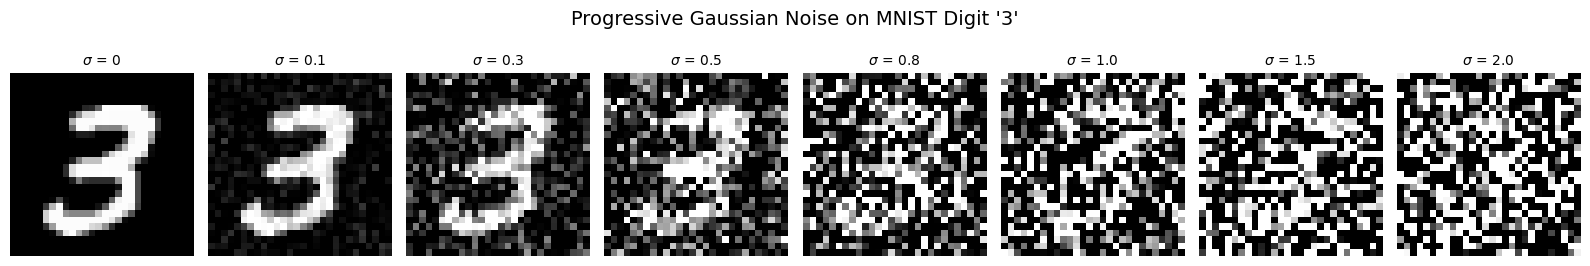

As sigma increases, the image gradually becomes pure noise.
Diffusion models learn to REVERSE this process: from noise back to data.


In [11]:
# Download a single MNIST digit
mnist = torchvision.datasets.MNIST(root="./data", train=True, download=True,
                                   transform=transforms.ToTensor())

# Pick a nice digit (a '3')
img, label = mnist[7]  # shape: (1, 28, 28), values in [0, 1]
img_np = img.squeeze().numpy()

# Noise levels to demonstrate
sigmas = [0, 0.1, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0]

fig, axes = plt.subplots(1, len(sigmas), figsize=(16, 2.5))

for ax, sigma in zip(axes, sigmas):
    if sigma == 0:
        noisy = img_np.copy()
    else:
        noise = np.random.randn(*img_np.shape) * sigma
        noisy = img_np + noise

    ax.imshow(noisy, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"$\\sigma$ = {sigma}", fontsize=10)
    ax.axis("off")

fig.suptitle(f"Progressive Gaussian Noise on MNIST Digit '{label}'", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print("As sigma increases, the image gradually becomes pure noise.")
print("Diffusion models learn to REVERSE this process: from noise back to data.")

## Summary & Key Takeaways

1. **Univariate Gaussians** are fully described by mean $\mu$ and variance $\sigma^2$. The mean shifts the bell curve; the variance controls its width.

2. **Histogram convergence** illustrates the Law of Large Numbers: more samples yield a better approximation of the true density.

3. **Central Limit Theorem**: summing independent random variables (of any distribution) produces a Gaussian in the limit. This is one reason Gaussians appear so naturally.

4. **Multivariate Gaussians** extend to higher dimensions. The covariance matrix encodes correlations and determines contour shapes (circles, axis-aligned ellipses, or rotated ellipses).

5. **Marginal distributions** are obtained by integrating out variables. For Gaussians, marginals remain Gaussian.

6. **Conditional distributions** are also Gaussian. Conditioning on one variable shifts the mean and reduces the variance of the other, proportional to the correlation.

7. **The reparameterization trick** ($z = \mu + \sigma \cdot \epsilon$) enables gradient-based optimisation through sampling operations -- a key ingredient of VAEs.

8. **Progressive Gaussian noise** is the foundation of diffusion models: the forward process gradually destroys data, and the learned reverse process reconstructs it.

---

**Next notebook:** We will build on these foundations to implement a simple denoising model and explore noise schedules in detail.